# Laboratorio 01 - Exploración de Datos

- **Curso:** Manejo de Datos para IA — Trimestre 2
- **Tema:** Detección de problemas comunes en conjuntos de datos (EDA)
- **Alumno:** Edgar Estuardo Dueñas de León
- **Carnet:** 0910296

## Objetivo

Analizar los tres conjuntos de datos almacenados en las bases de datos MySQL que estoy corriendo utilizando docker:
`pia_data_01`, `pia_data_02` y `pia_data_03` (todas con la tabla `salaries`),
alojadas en el entorno de *docker compose*, para **detectar problemas comunes**
de calidad de datos:

1. **Datos faltantes** (*Missing Data*)
2. **Problemas de escala** (*Scaling Issues*)
3. **Clases desbalanceadas** (*Imbalanced Classes*)
4. **Valores anómalos** (*Outliers*)
5. **Problemas de formato**
6. **Problemas de estandarización**

Adicionalmente se analizará la **distribución de cada variable** para identificar patrones, sesgos y particularidades (formas de la distribución, mezcla de
distribuciones, etc.).

## Conexión a base de datos

- **Host:** `0.0.0.0`  **Puerto:** `10101`
- **Usuario:** `root`  **Contraseña:** `admin123`
- **Bases de datos:** `pia_data_01`, `pia_data_02`, `pia_data_03`
- **Tabla:** `salaries`

## 1. Importación de librerías y configuración

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# python-docx para los informes
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Conexión a las bases de datos y carga de los datos

Cada base de datos contiene una única tabla `salaries` con el mismo esquema.
Se cargan las tres en un diccionario de *DataFrames*.

In [4]:
DB_CONFIG = dict(host="0.0.0.0", port=10101, user="root", password="admin123")
DB_NAMES = ["pia_data_01", "pia_data_02", "pia_data_03"]

def load_db(name):
    url = (f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
           f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{name}")
    engine = create_engine(url)
    df = pd.read_sql("SELECT * FROM salaries", engine)
    engine.dispose()
    return df

datasets = {name: load_db(name) for name in DB_NAMES}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} filas x {df.shape[1]} columnas")

pia_data_01: 710 filas x 15 columnas
pia_data_02: 1050 filas x 15 columnas
pia_data_03: 2333 filas x 15 columnas


In [9]:
# Vista previa del primer conjunto de datos
datasets["pia_data_01"].head()

,id,gender,age,country,married,family_members,industry,income_flux,outgoing_flux,education_level,years_of_experience,employment_type,remote_work_percentage,currency,salary_satisfaction
0,1,Female,30.0,Guatemala,0,3,Pharmaceutical,0.0,3350.0,Other,7,Unemployed,0,GTQ,3
1,2,Female,37.0,Guatemala,0,1,Pharmaceutical,14380.0,9343.0,Master,10,Full-time,32,GTQ,5
2,3,Female,59.0,Guatemala,1,2,Health,14282.0,9239.0,Bachelor,22,Unemployed,0,GTQ,3
3,4,Female,38.0,Guatemala,1,0,Economics,12862.0,7010.0,Master,11,None,19,GTQ,3
4,5,Male,31.0,Guatemala,0,4,Technology,2057.0,693.0,Bachelor,4,Freelance,42,GTQ,2


In [11]:
# Esquema / tipos de datos (idéntico en las tres bases)
datasets["pia_data_01"].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      710 non-null    int64  
 1   gender                  675 non-null    object 
 2   age                     696 non-null    float64
 3   country                 710 non-null    object 
 4   married                 710 non-null    int64  
 5   family_members          710 non-null    int64  
 6   industry                710 non-null    object 
 7   income_flux             684 non-null    float64
 8   outgoing_flux           675 non-null    float64
 9   education_level         689 non-null    object 
 10  years_of_experience     710 non-null    int64  
 11  employment_type         689 non-null    object 
 12  remote_work_percentage  710 non-null    int64  
 13  currency                675 non-null    object 
 14  salary_satisfaction     710 non-null    in

## 3. Definición de variables

Clasificamos las columnas de la tabla `salaries` según su naturaleza, lo cual
guía el tipo de análisis que se aplica a cada una.

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | Identificador | Clave primaria autoincremental |
| `gender` | Categórica (binaria) | Género (Male / Female) |
| `age` | Numérica continua | Edad (≥ 18) |
| `country` | Categórica | País |
| `married` | Booleana | Estado civil (0/1) |
| `family_members` | Numérica discreta | Número de miembros de la familia (0–5) |
| `industry` | Categórica | Industria / sector |
| `income_flux` | Numérica continua | Flujo de ingresos |
| `outgoing_flux` | Numérica continua | Flujo de egresos |
| `education_level` | Categórica ordinal | Nivel educativo |
| `years_of_experience` | Numérica discreta | Años de experiencia |
| `employment_type` | Categórica | Tipo de empleo |
| `remote_work_percentage` | Numérica continua | % de trabajo remoto (0–100) |
| `currency` | Categórica | Moneda |
| `salary_satisfaction` | Categórica ordinal | Satisfacción salarial (1–5) |

In [12]:
ID_COL = "id"
NUMERIC_CONT = ["age", "income_flux", "outgoing_flux",
                "remote_work_percentage"]
NUMERIC_DISC = ["family_members", "years_of_experience"]
CATEGORICAL  = ["gender", "country", "industry", "education_level",
                "employment_type", "currency"]
BOOLEAN      = ["married"]
ORDINAL      = ["education_level", "salary_satisfaction"]
TARGET_LIKE  = ["salary_satisfaction"]   # variable objetivo candidata

# Orden lógico para variables ordinales
EDU_ORDER = ["High School", "Bachelor", "Master", "PhD", "Other"]

NUMERIC_ALL = NUMERIC_CONT + NUMERIC_DISC + ["salary_satisfaction"]
ALL_FEATURES = [c for c in datasets["pia_data_01"].columns if c != ID_COL]
print("Características a analizar:", ALL_FEATURES)

Características a analizar: ['gender', 'age', 'country', 'married', 'family_members', 'industry', 'income_flux', 'outgoing_flux', 'education_level', 'years_of_experience', 'employment_type', 'remote_work_percentage', 'currency', 'salary_satisfaction']


## 4. Datos faltantes (*Missing Data*)

Cuantificamos los valores nulos por columna en cada base de datos y
visualizamos su patrón.

In [13]:
def missing_report(df):
    miss = df.isnull().sum()
    pct = (miss / len(df) * 100).round(2)
    out = pd.DataFrame({"n_faltantes": miss, "%_faltantes": pct})
    return out[out.n_faltantes > 0].sort_values("%_faltantes", ascending=False)

for name, df in datasets.items():
    print("="*55)
    print(f"{name} — total filas: {len(df)}")
    rep = missing_report(df)
    if rep.empty:
        print("Sin valores faltantes.")
    else:
        print(rep.to_string())

pia_data_01 — total filas: 710
                 n_faltantes  %_faltantes
gender                    35         4.93
outgoing_flux             35         4.93
currency                  35         4.93
income_flux               26         3.66
education_level           21         2.96
employment_type           21         2.96
age                       14         1.97
pia_data_02 — total filas: 1050
                 n_faltantes  %_faltantes
gender                    52         4.95
outgoing_flux             52         4.95
currency                  52         4.95
income_flux               40         3.81
education_level           31         2.95
employment_type           31         2.95
age                       21         2.00
pia_data_03 — total filas: 2333
                 n_faltantes  %_faltantes
gender                   116         4.97
outgoing_flux            116         4.97
currency                 116         4.97
income_flux               87         3.73
education_level        

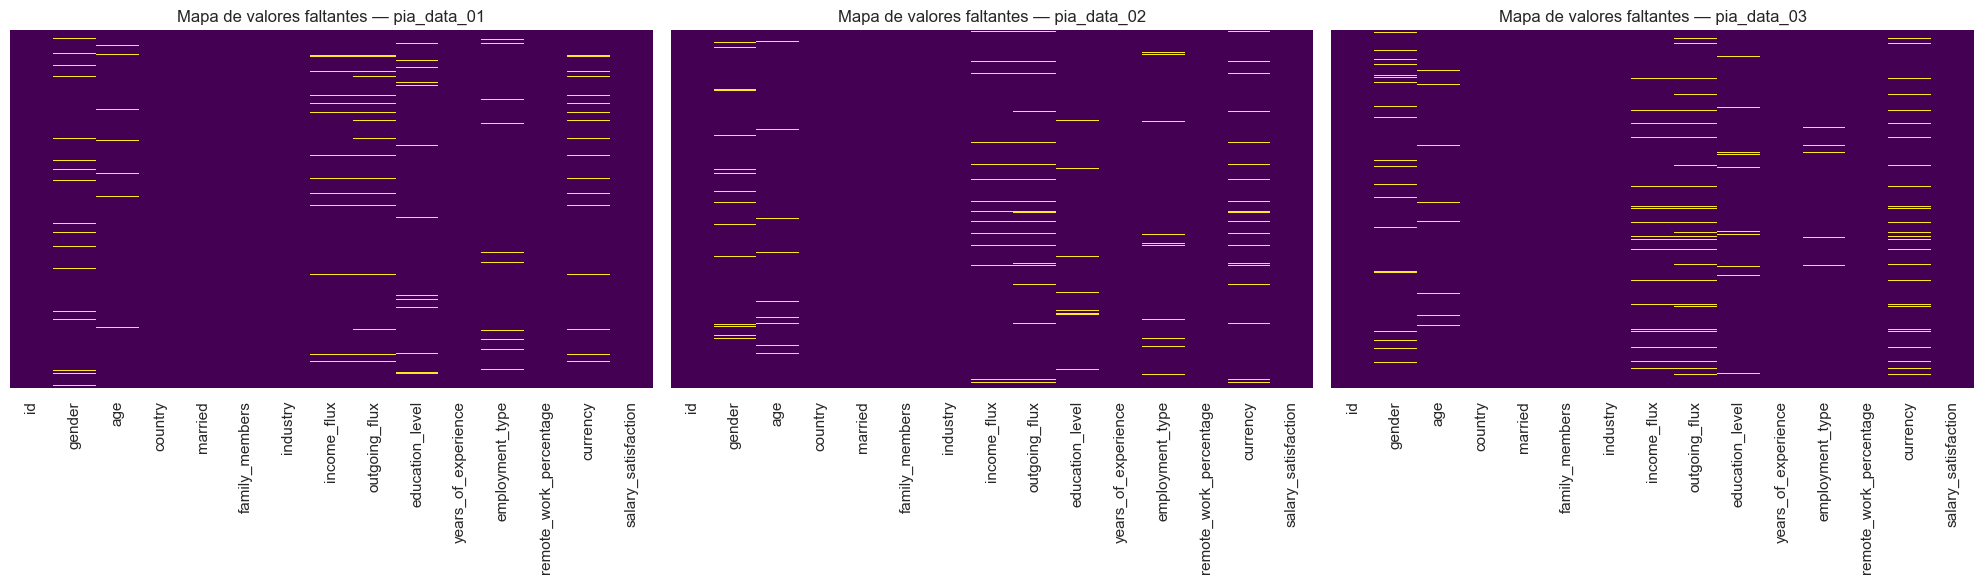

In [14]:
# Visualización del patrón de valores faltantes
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, df) in zip(axes, datasets.items()):
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
                cmap="viridis", ax=ax)
    ax.set_title(f"Mapa de valores faltantes — {name}")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [15]:

# Hipótesis: cuando 'currency' es nula, 'income_flux' y 'outgoing_flux' también lo son.
for name, df in datasets.items():
    cur_null = df.currency.isnull()
    print(f"{name}: currency nula = {cur_null.sum()} | "
          f"de ellas con outgoing_flux nulo = {(cur_null & df.outgoing_flux.isnull()).sum()} | "
          f"con income_flux nulo = {(cur_null & df.income_flux.isnull()).sum()}")

pia_data_01: currency nula = 35 | de ellas con outgoing_flux nulo = 35 | con income_flux nulo = 26
pia_data_02: currency nula = 52 | de ellas con outgoing_flux nulo = 52 | con income_flux nulo = 40
pia_data_03: currency nula = 116 | de ellas con outgoing_flux nulo = 116 | con income_flux nulo = 87


**Hallazgo:** los valores faltantes de `currency`, `income_flux` y
`outgoing_flux` están **correlacionados** (faltante estructurado / MAR): siempre
que `currency` es nula, `outgoing_flux` también lo es. Esto sugiere que el flujo
económico completo (moneda + ingresos + egresos) se pierde en bloque para ciertos
registros.

## 5. Problemas de escala (*Scaling Issues*)

Comparamos los rangos y magnitudes de las variables numéricas. Diferencias de
varios órdenes de magnitud indican la necesidad de **normalización /
estandarización** antes de usar algoritmos sensibles a la escala.

In [16]:
for name, df in datasets.items():
    print("="*55, name)
    print(df[NUMERIC_CONT + NUMERIC_DISC].describe().round(2).to_string())

======================================================= pia_data_01
          age  income_flux  outgoing_flux  remote_work_percentage  family_members  years_of_experience
count  696.00       684.00         675.00                  710.00           710.0               710.00
mean    40.92      7451.68        3843.85                   20.83             2.5                10.98
std     13.91      6825.57        3243.61                   16.02             1.7                 7.03
min     18.00         0.00         201.00                    0.00             0.0                 0.00
25%     28.00      1000.00        1091.50                    0.00             1.0                 5.00
50%     40.00      6076.00        3190.00                   24.00             2.0                11.00
75%     54.00     12173.50        5669.00                   33.00             4.0                17.00
max     64.00     30466.00       17867.00                   57.00             5.0                25.00
=====

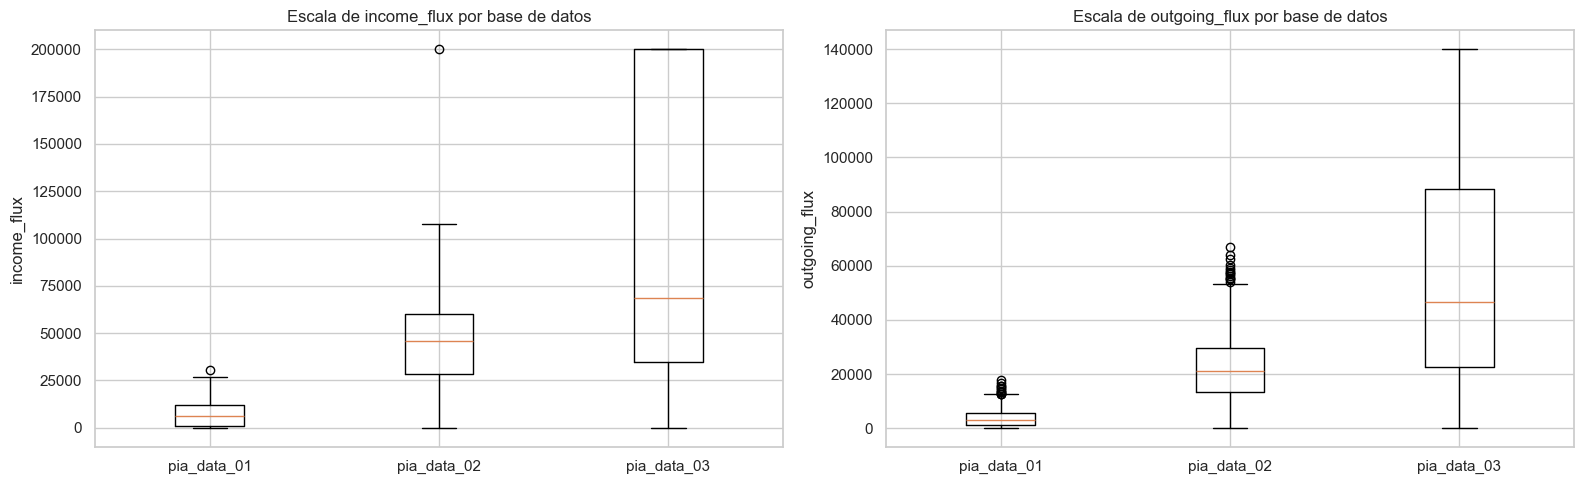

Rango de magnitudes (mediana de income_flux):
  pia_data_01: mediana income = 6,076
  pia_data_02: mediana income = 45,911
  pia_data_03: mediana income = 68,776


In [17]:
# Comparación de la escala de income_flux y outgoing_flux entre bases
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for col, ax in zip(["income_flux", "outgoing_flux"], axes):
    data = [datasets[n][col].dropna() for n in DB_NAMES]
    ax.boxplot(data, labels=DB_NAMES, showfliers=True)
    ax.set_title(f"Escala de {col} por base de datos")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

print("Rango de magnitudes (mediana de income_flux):")
for name, df in datasets.items():
    print(f"  {name}: mediana income = {df.income_flux.median():,.0f}")

**Hallazgo:** `income_flux` y `outgoing_flux` operan en **escalas muy
distintas** entre bases (decenas de miles vs. cientos de miles) y dentro de una
misma base conviven con variables como `age` (18–64) o `remote_work_percentage`
(0–100). Estas variables **requieren escalamiento** (StandardScaler / MinMaxScaler)
antes de ser usadas en modelos basados en distancias o gradientes.

## 6. Clases desbalanceadas (*Imbalanced Classes*)

Revisamos la distribución de frecuencias de las variables categóricas y de la
variable objetivo candidata (`salary_satisfaction`). Calculamos un **ratio de
balance** = frecuencia mínima / frecuencia máxima (1.0 = perfectamente
balanceado).

In [18]:
def balance_ratio(series):
    vc = series.dropna().value_counts()
    if len(vc) <= 1:
        return 0.0, vc
    return round(vc.min() / vc.max(), 3), vc

CAT_TO_CHECK = ["gender", "country", "industry", "education_level",
                "employment_type", "currency", "married",
                "family_members", "salary_satisfaction"]

for name, df in datasets.items():
    print("="*55, name)
    for col in CAT_TO_CHECK:
        ratio, vc = balance_ratio(df[col])
        estado = ("CONSTANTE" if len(vc) <= 1 else
                  "DESBALANCEADA" if ratio < 0.5 else "balanceada")
        print(f"  {col:<22} clases={len(vc):<2} ratio={ratio:<6} -> {estado}")

======================================================= pia_data_01
  gender                 clases=2  ratio=0.824  -> balanceada
  country                clases=1  ratio=0.0    -> CONSTANTE
  industry               clases=8  ratio=0.736  -> balanceada
  education_level        clases=5  ratio=0.111  -> DESBALANCEADA
  employment_type        clases=4  ratio=0.758  -> balanceada
  currency               clases=1  ratio=0.0    -> CONSTANTE
  married                clases=2  ratio=0.919  -> balanceada
  family_members         clases=6  ratio=0.853  -> balanceada
  salary_satisfaction    clases=5  ratio=0.839  -> balanceada
======================================================= pia_data_02
  gender                 clases=2  ratio=0.949  -> balanceada
  country                clases=1  ratio=0.0    -> CONSTANTE
  industry               clases=10 ratio=0.683  -> balanceada
  education_level        clases=5  ratio=0.125  -> DESBALANCEADA
  employment_type        clases=4  ratio=0.914  -> bala

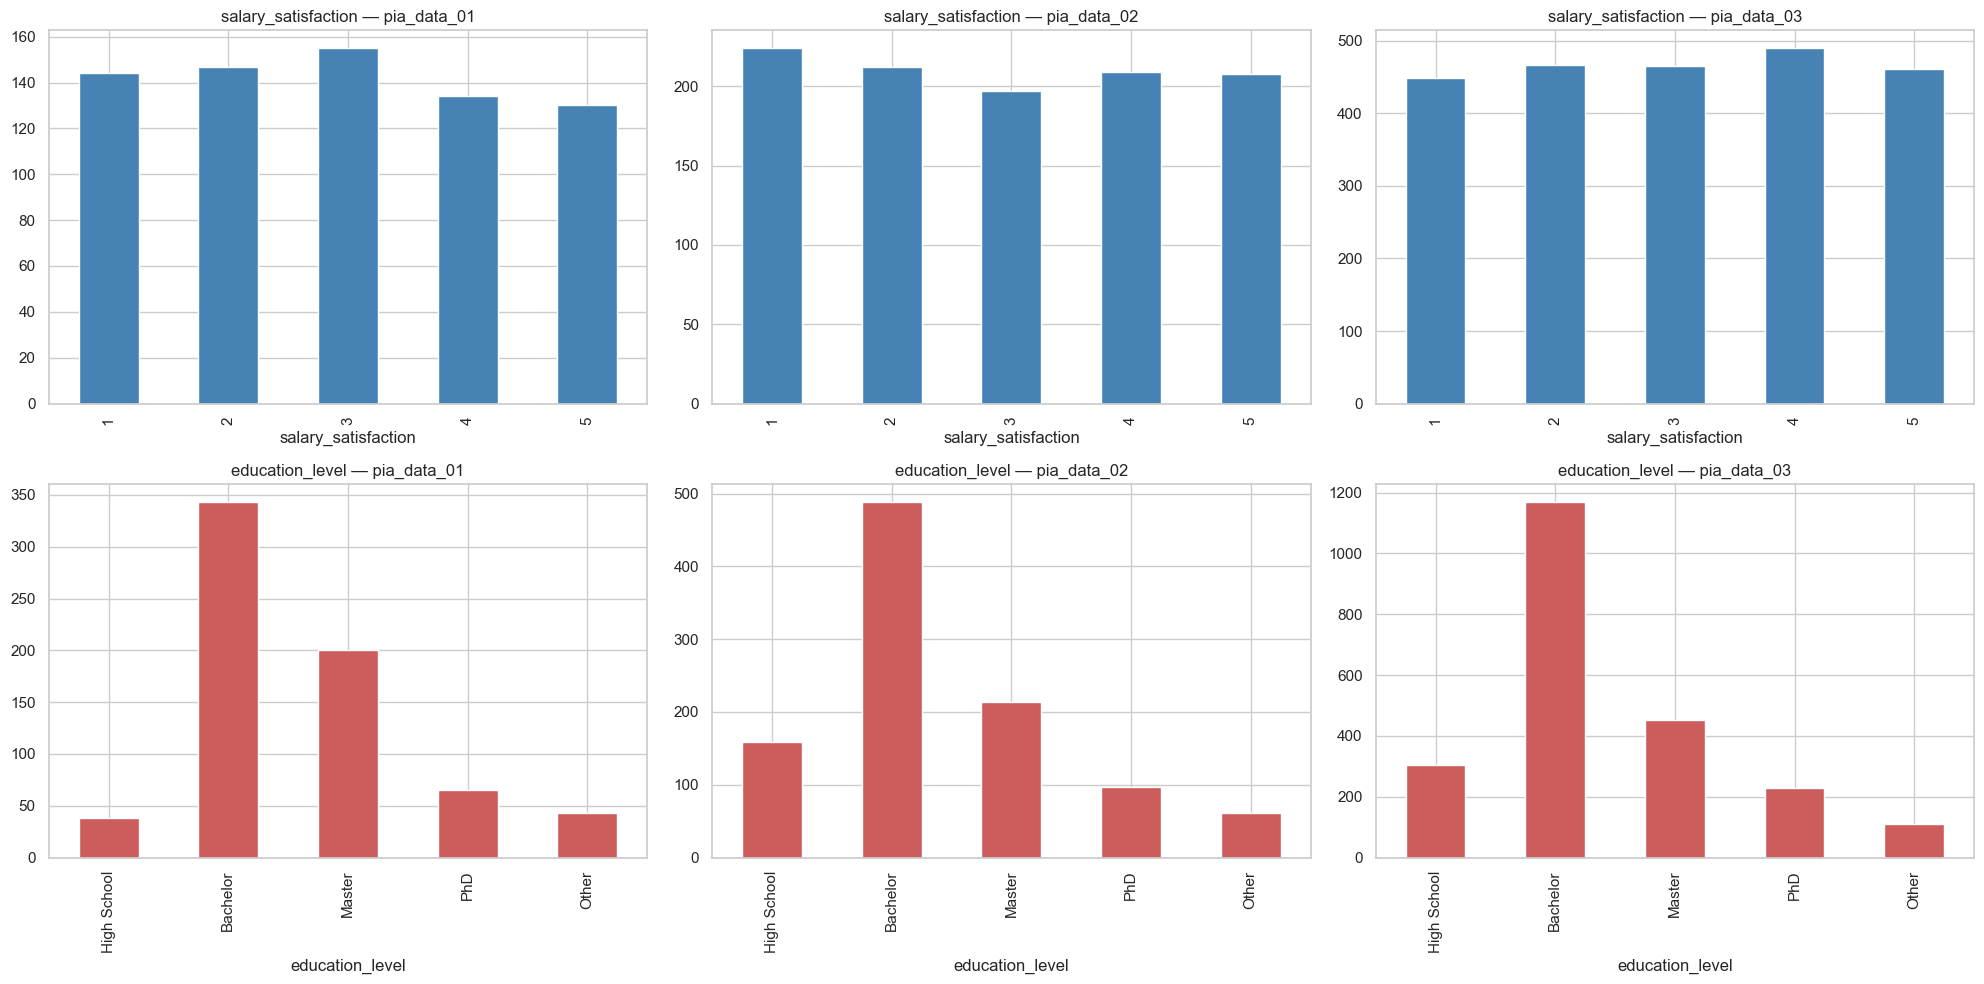

In [19]:
# Gráficos de barras para variables clave (target y educación)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for j, name in enumerate(DB_NAMES):
    df = datasets[name]
    df.salary_satisfaction.value_counts().sort_index().plot(
        kind="bar", ax=axes[0, j], color="steelblue")
    axes[0, j].set_title(f"salary_satisfaction — {name}")
    order = [e for e in EDU_ORDER if e in df.education_level.unique()]
    df.education_level.value_counts().reindex(order).plot(
        kind="bar", ax=axes[1, j], color="indianred")
    axes[1, j].set_title(f"education_level — {name}")
plt.tight_layout()
plt.show()

**Hallazgo:** la variable objetivo `salary_satisfaction` y la mayoría de
las categóricas están **razonablemente balanceadas**. La excepción es
`education_level`, donde **`Bachelor` domina** (clase mayoritaria) frente a
`High School`, `PhD` y `Other`. Además `country` y `currency` son **constantes**
(una sola clase) en `pia_data_01` (Guatemala/Q) y `pia_data_02` (USA/$), por
lo que no aportan variabilidad en esas bases.

## 7. Valores anómalos (*Outliers*)

Identifique que outliers en las variables numéricas continuas mediante el método del
**rango intercuartílico (IQR)**: un valor es atípico si está fuera de
`[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`. También buscamos **artefactos de techo
(*capping*)**: valores idénticos al máximo que se repiten anormalmente.

In [20]:
def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (s < low) | (s > high)
    return int(mask.sum()), round(low, 2), round(high, 2)

for name, df in datasets.items():
    print("="*55, name)
    for col in NUMERIC_CONT:
        n_out, low, high = iqr_outliers(df[col])
        # detección de capping en el máximo
        s = df[col].dropna()
        max_val = s.max()
        n_max = int((s == max_val).sum())
        cap = f" | CAPPING: {n_max} valores == {max_val:,.0f}" if n_max > 0.05*len(s) and n_max > 5 else ""
        print(f"  {col:<24} outliers_IQR={n_out:<4} límites=[{low}, {high}]{cap}")

======================================================= pia_data_01
  age                      outliers_IQR=0    límites=[-11.0, 93.0]
  income_flux              outliers_IQR=1    límites=[-15760.25, 28933.75]
  outgoing_flux            outliers_IQR=12   límites=[-5774.75, 12535.25]
  remote_work_percentage   outliers_IQR=0    límites=[-49.5, 82.5]
======================================================= pia_data_02
  age                      outliers_IQR=0    límites=[-8.0, 88.0]
  income_flux              outliers_IQR=1    límites=[-19279.5, 107902.5]
  outgoing_flux            outliers_IQR=14   límites=[-10634.62, 53858.38]
  remote_work_percentage   outliers_IQR=0    límites=[-79.5, 132.5]
======================================================= pia_data_03
  age                      outliers_IQR=0    límites=[-5.5, 86.5]
  income_flux              outliers_IQR=0    límites=[-213190.62, 447914.38] | CAPPING: 765 valores == 200,000
  outgoing_flux            outliers_IQR=0    límites=

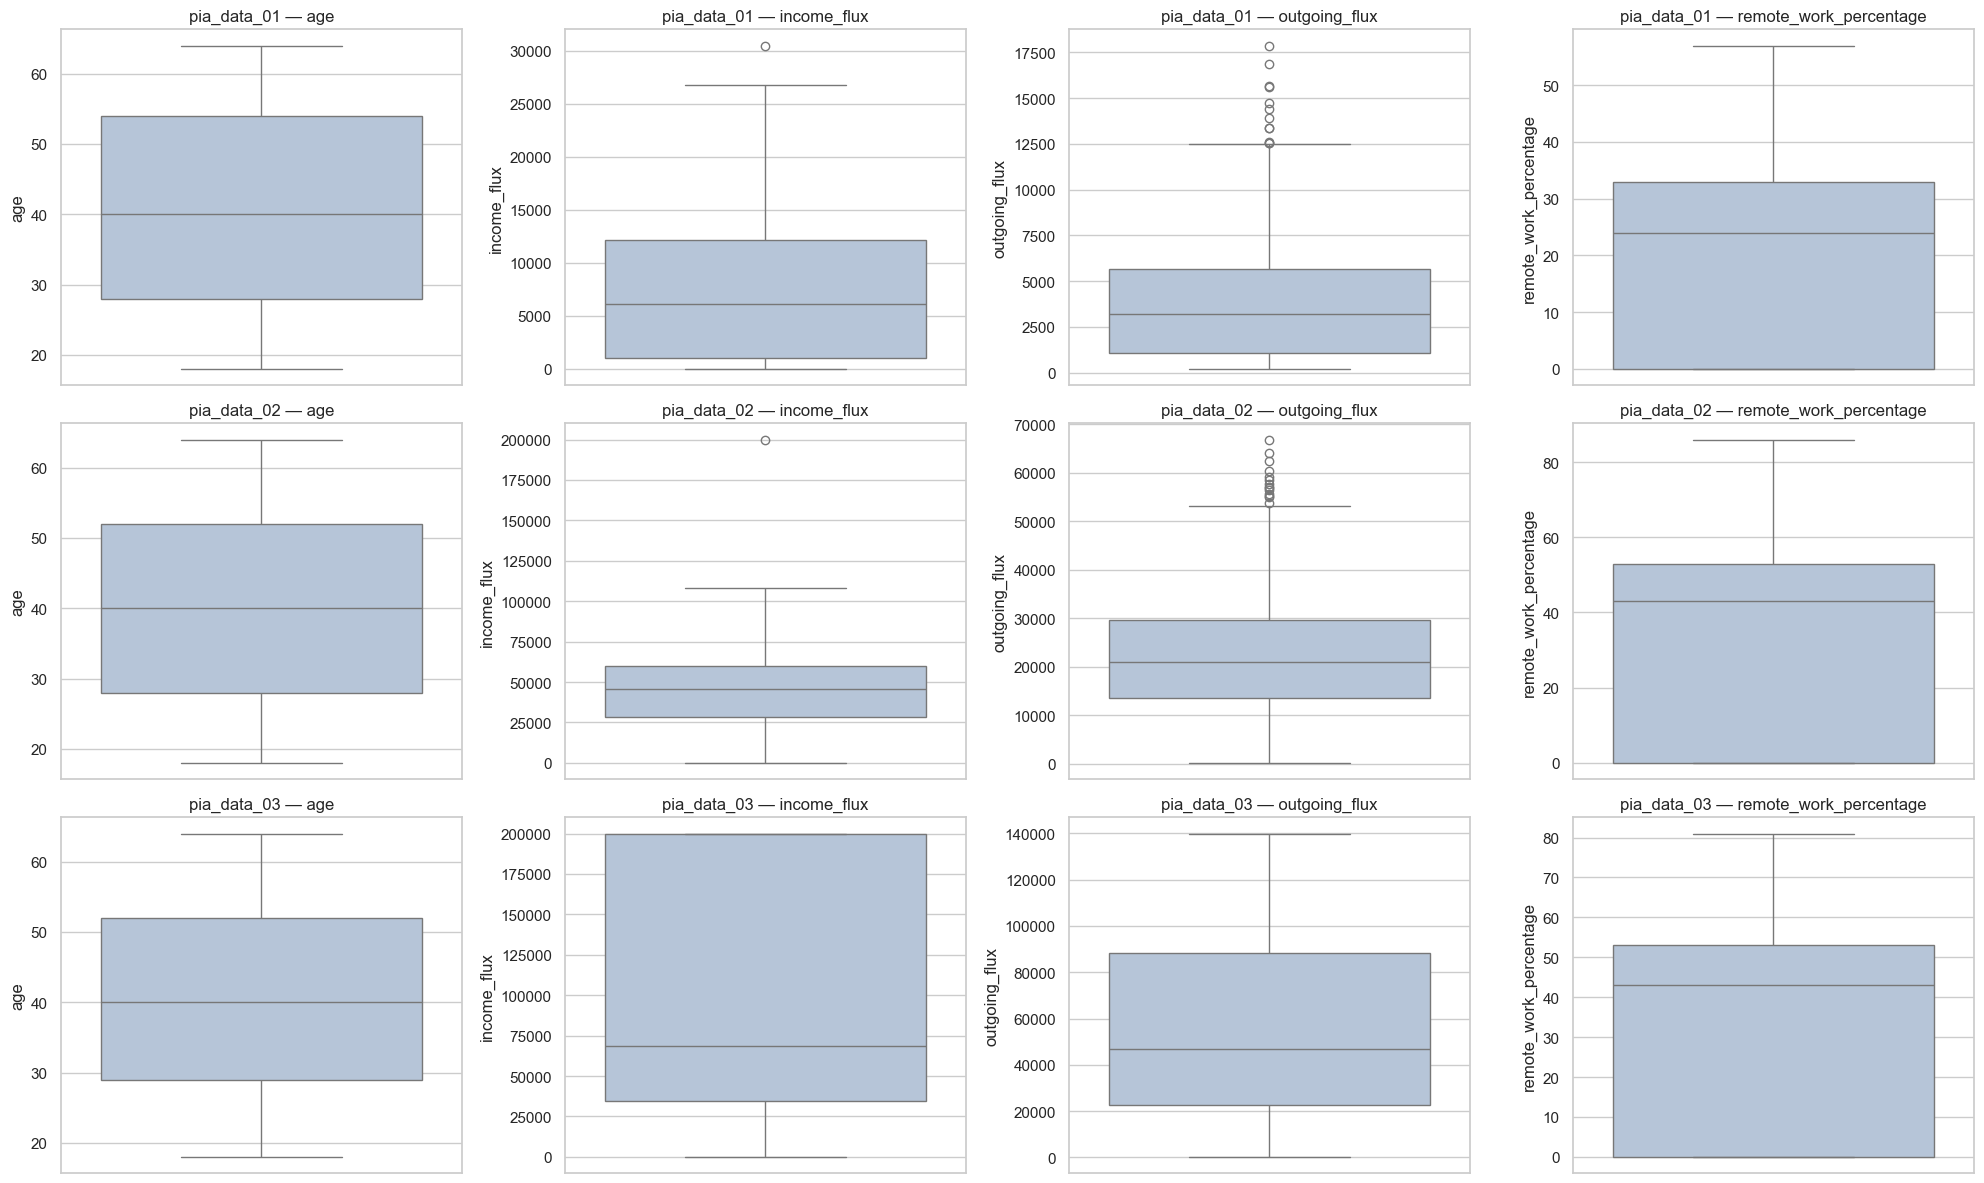

In [21]:
# Boxplots de las variables continuas por base de datos
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for i, name in enumerate(DB_NAMES):
    df = datasets[name]
    for j, col in enumerate(NUMERIC_CONT):
        sns.boxplot(y=df[col], ax=axes[i, j], color="lightsteelblue")
        axes[i, j].set_title(f"{name} — {col}")
plt.tight_layout()
plt.show()

**Hallazgo:** se detectan outliers superiores en `outgoing_flux`
(`pia_data_01` y `pia_data_02`). El hallazgo más relevante es un **artefacto de
techo (*capping*)** en `income_flux` de **`pia_data_03`**: cientos de registros
tienen exactamente `200000`, lo que indica que los ingresos fueron **truncados a
un valor máximo** (no es ruido aleatorio sino un límite artificial). El valor `0`
en `income_flux` corresponde a personas `Unemployed`, lo que genera un pico
legítimo en el extremo inferior.

## 8. Problemas de formato y estandarización

Revisamos los **tipos de datos** y la **representación** de los valores:

- `married` es booleano pero se almacena como entero `0/1`.
- `age` contiene edades enteras almacenadas como **decimal** (`30.0`).
- Variables categóricas en texto requieren **codificación** para modelado.
- En el código fuente, `remote_work_percentage` traía artefactos de punto
  flotante (p. ej. `56.99999999999999`); MySQL los almacenó como `INT`.
- `currency` mezcla varias monedas en `pia_data_03`, por lo que `income_flux`/
  `outgoing_flux` **no son comparables** sin convertir a una moneda común
  (problema de estandarización).

In [22]:
for name, df in datasets.items():
    print("="*55, name)
    print(df.dtypes.to_string())
    # ¿age son todos enteros almacenados como float?
    age_no_null = df.age.dropna()
    es_entero = (age_no_null == age_no_null.round()).all()
    print(f"  -> age: dtype={df.age.dtype}, ¿todos enteros? {es_entero} (formato float innecesario)")
    print(f"  -> married: valores únicos = {sorted(df.married.dropna().unique())} (booleano como entero)")
    print(f"  -> monedas presentes: {sorted(df.currency.dropna().unique())}")

======================================================= pia_data_01
id                          int64
gender                     object
age                       float64
country                    object
married                     int64
family_members              int64
industry                   object
income_flux               float64
outgoing_flux             float64
education_level            object
years_of_experience         int64
employment_type            object
remote_work_percentage      int64
currency                   object
salary_satisfaction         int64
  -> age: dtype=float64, ¿todos enteros? True (formato float innecesario)
  -> married: valores únicos = [np.int64(0), np.int64(1)] (booleano como entero)
  -> monedas presentes: ['GTQ']
======================================================= pia_data_02
id                          int64
gender                     object
age                       float64
country                    object
married                     int

## 9. Análisis de la distribución de cada variable

Para cada variable numérica calcule asimetría (*skewness*) y curtosis, y
visualizamos histogramas para identificar la **forma** de la distribución
(uniforme, campana, sesgada, bimodal) y la presencia de **múltiples
distribuciones** (mezclas).

In [23]:
def skew_label(sk):
    if sk > 0.5:  return "sesgo a la derecha (positivo)"
    if sk < -0.5: return "sesgo a la izquierda (negativo)"
    return "aproximadamente simétrica"

for name, df in datasets.items():
    print("="*55, name)
    for col in NUMERIC_CONT + NUMERIC_DISC:
        s = df[col].dropna()
        sk = skew(s); ku = kurtosis(s)
        zero_share = (s == 0).mean()
        nota = " | pico notable en 0 (posible mezcla)" if zero_share > 0.08 else ""
        print(f"  {col:<24} skew={sk:6.2f} ({skew_label(sk)}) kurt={ku:6.2f}{nota}")

======================================================= pia_data_01
  age                      skew= -0.01 (aproximadamente simétrica) kurt= -1.28
  income_flux              skew=  0.77 (sesgo a la derecha (positivo)) kurt= -0.25 | pico notable en 0 (posible mezcla)
  outgoing_flux            skew=  1.14 (sesgo a la derecha (positivo)) kurt=  1.17
  remote_work_percentage   skew= -0.07 (aproximadamente simétrica) kurt= -1.27 | pico notable en 0 (posible mezcla)
  family_members           skew= -0.01 (aproximadamente simétrica) kurt= -1.26 | pico notable en 0 (posible mezcla)
  years_of_experience      skew=  0.04 (aproximadamente simétrica) kurt= -1.14
======================================================= pia_data_02
  age                      skew=  0.07 (aproximadamente simétrica) kurt= -1.22
  income_flux              skew=  0.02 (aproximadamente simétrica) kurt=  0.85 | pico notable en 0 (posible mezcla)
  outgoing_flux            skew=  0.71 (sesgo a la derecha (positivo)) kurt=

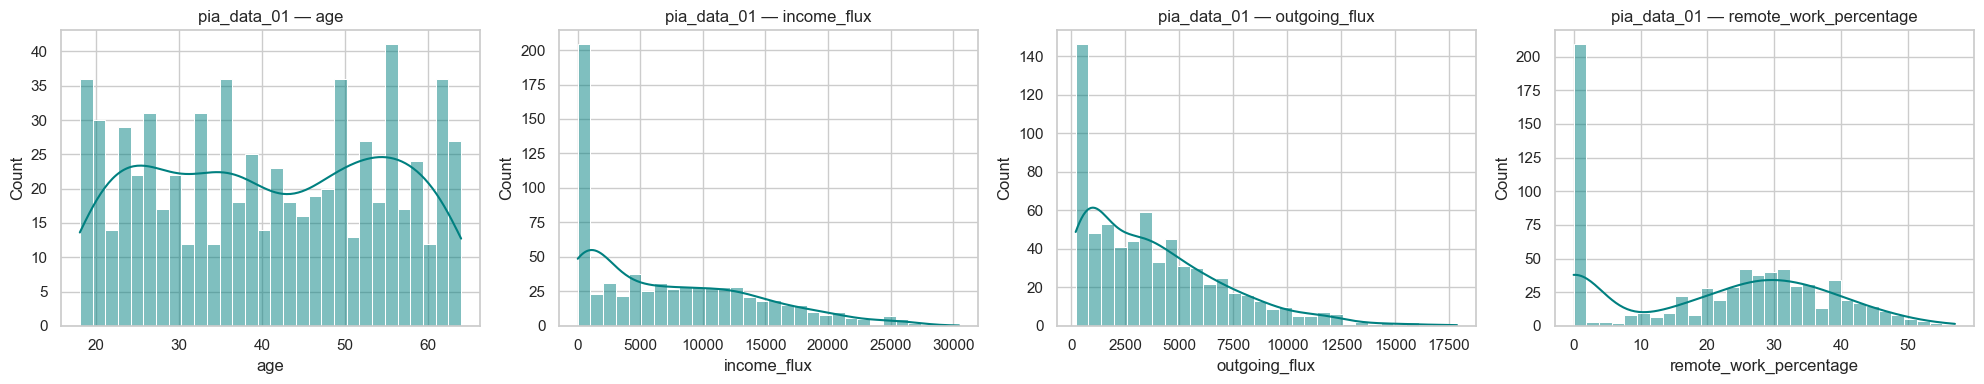

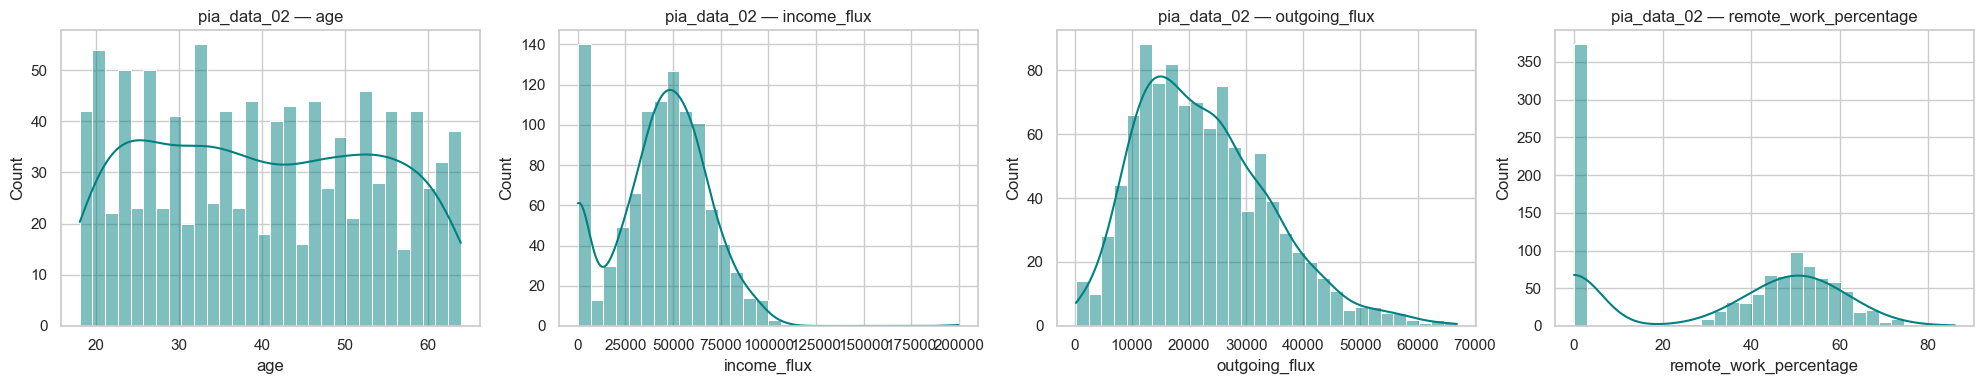

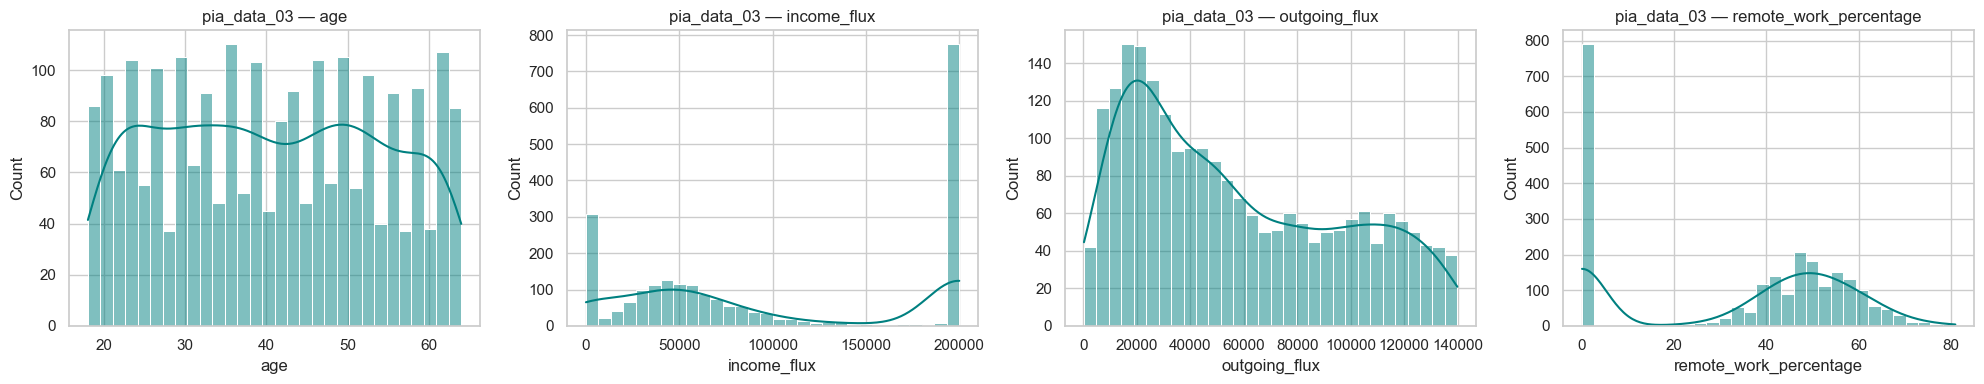

In [24]:
# Histogramas de las variables continuas
for name in DB_NAMES:
    df = datasets[name]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, col in zip(axes, NUMERIC_CONT):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color="teal", bins=30)
        ax.set_title(f"{name} — {col}")
    plt.tight_layout()
    plt.show()

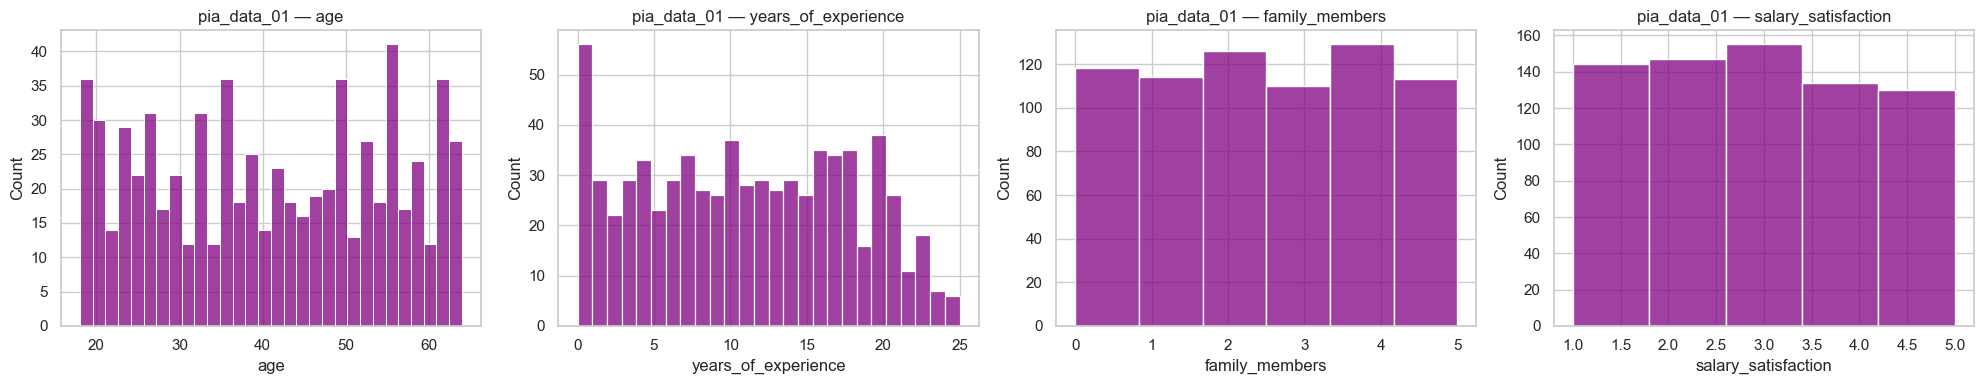

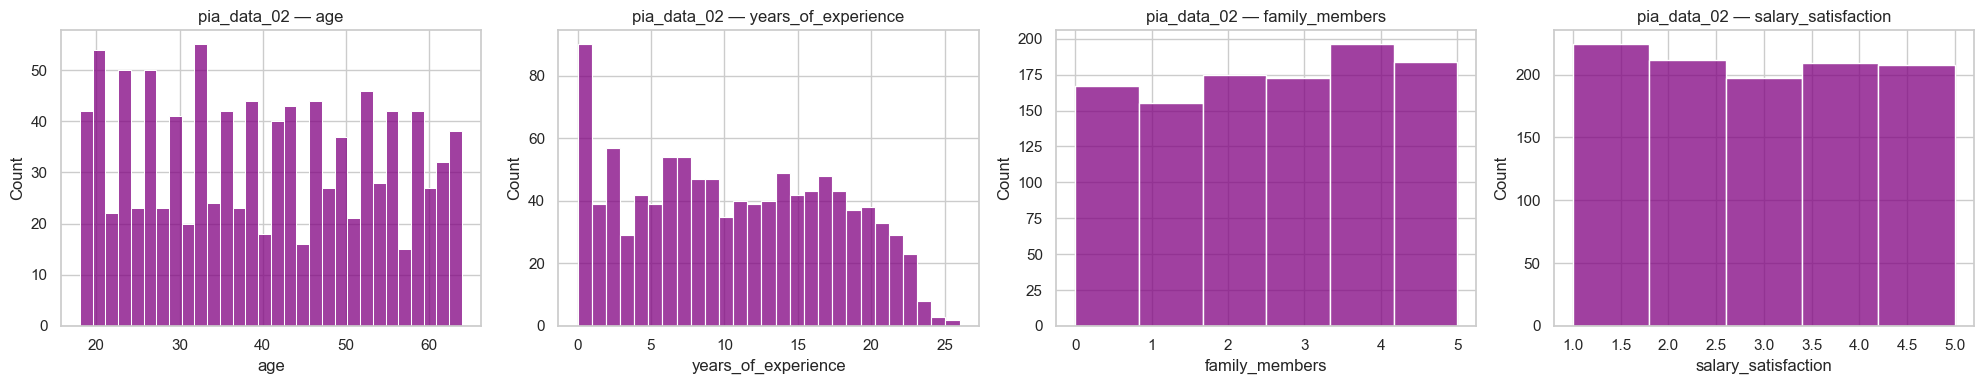

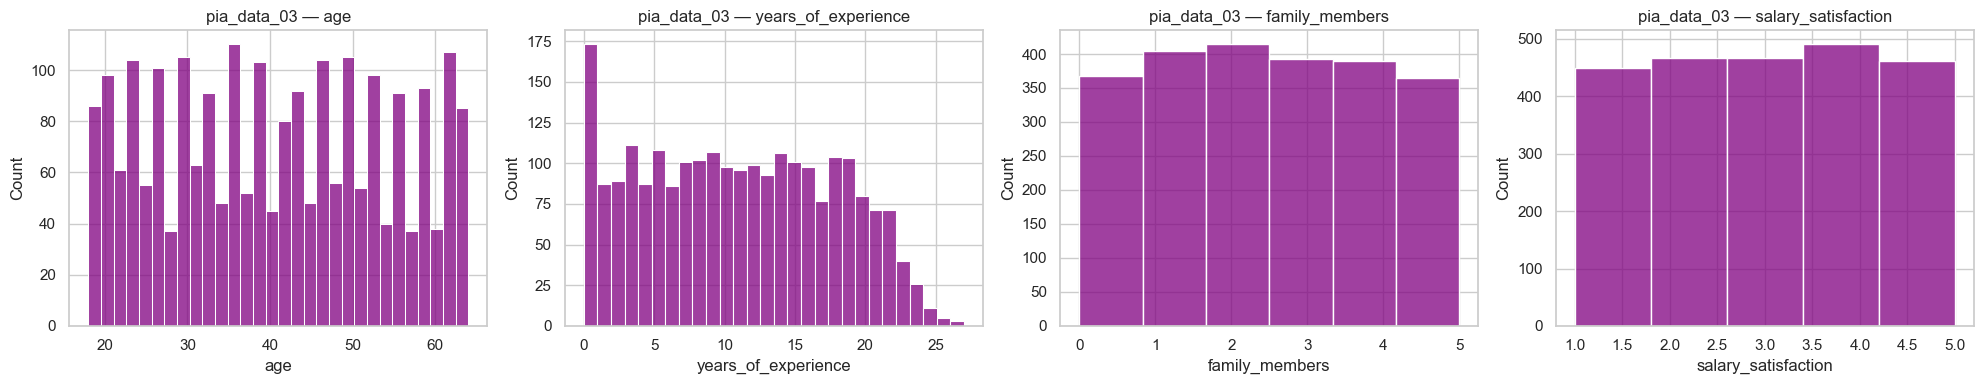

In [25]:
# Variables discretas / ordinales: age, experiencia, family, satisfacción
for name in DB_NAMES:
    df = datasets[name]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, col in zip(axes, ["age", "years_of_experience",
                              "family_members", "salary_satisfaction"]):
        sns.histplot(df[col].dropna(), ax=ax, color="purple",
                     bins=min(30, df[col].nunique()))
        ax.set_title(f"{name} — {col}")
    plt.tight_layout()
    plt.show()

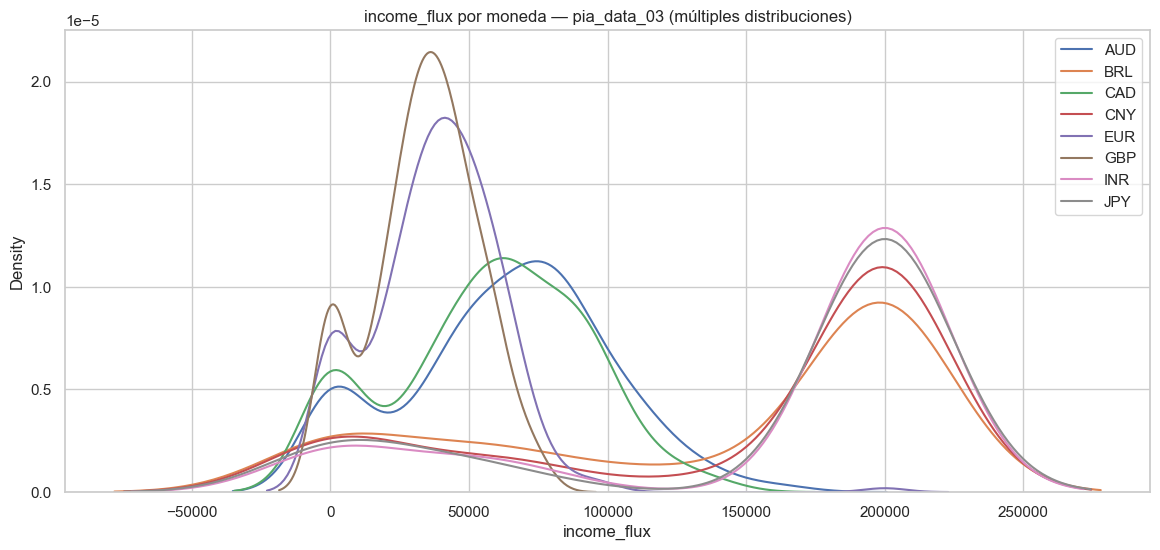

In [26]:
# Múltiples distribuciones: income_flux por moneda en pia_data_03
df3 = datasets["pia_data_03"]
plt.figure(figsize=(14, 6))
for cur in sorted(df3.currency.dropna().unique()):
    sub = df3.loc[df3.currency == cur, "income_flux"].dropna()
    sns.kdeplot(sub, label=cur)
plt.title("income_flux por moneda — pia_data_03 (múltiples distribuciones)")
plt.legend()
plt.show()

**Hallazgo:** `age`, `years_of_experience`, `family_members` y
`salary_satisfaction` presentan distribuciones **aproximadamente uniformes** y
simétricas. En cambio `income_flux`/`outgoing_flux` están **sesgadas a la derecha**
y muestran un **pico en 0** (desempleados) + el cuerpo principal → indicio de
**mezcla de distribuciones**. En `pia_data_03`, al separar `income_flux` por
moneda se confirman **múltiples distribuciones** superpuestas (cada moneda tiene
su propia escala).

## 10. Correlaciones entre variables numéricas

Como complemento, revise las correlaciones para detectar relaciones fuertes
(p. ej. ingresos vs. egresos).

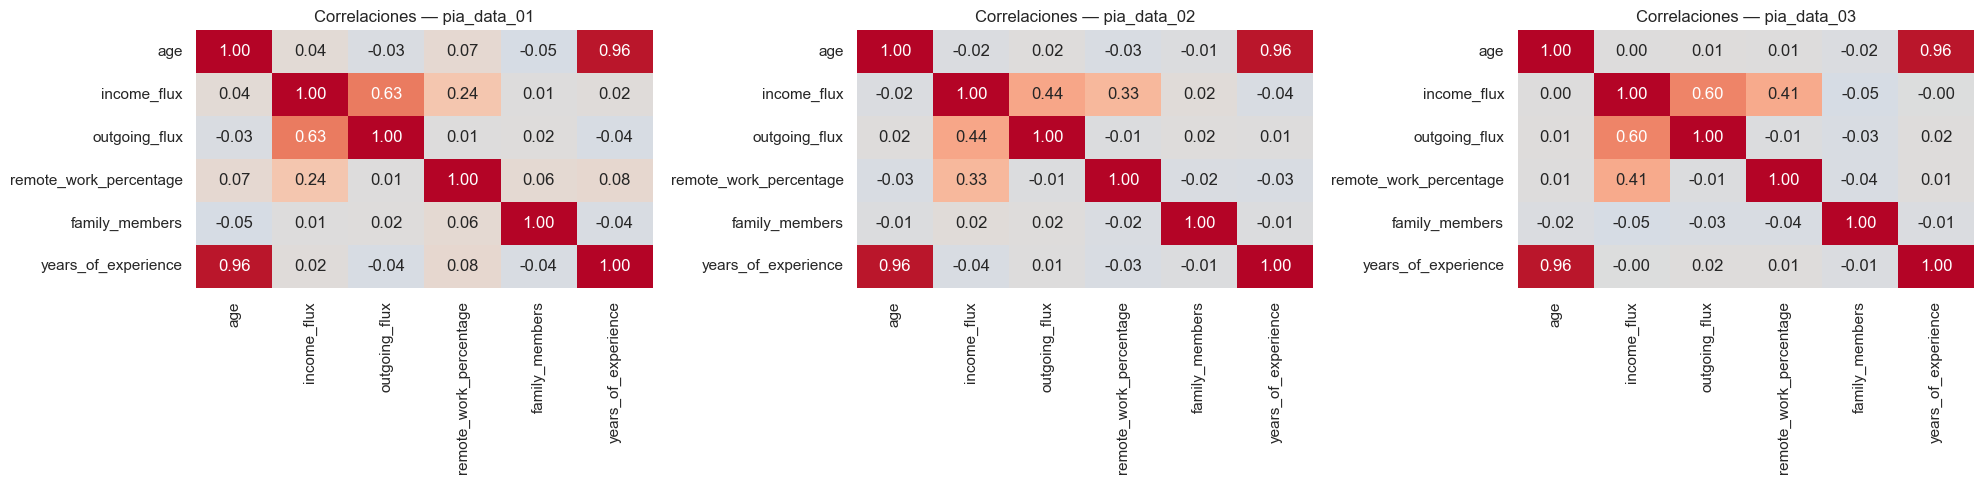

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, name in zip(axes, DB_NAMES):
    corr = datasets[name][NUMERIC_CONT + NUMERIC_DISC].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax, cbar=False)
    ax.set_title(f"Correlaciones — {name}")
plt.tight_layout()
plt.show()

## 11. Conclusiones finales

A partir del análisis exploratorio de las tres bases de datos (`pia_data_01`,
`pia_data_02`, `pia_data_03`), que comparten el mismo esquema `salaries`, he
concluido:

1. **Datos faltantes:** las tres bases presentan valores faltantes en
   `gender`, `age`, `education_level`, `employment_type`, `currency`,
   `income_flux` y `outgoing_flux` (≈ 2 %–5 % por columna). Los faltantes de
   `currency`, `income_flux` y `outgoing_flux` están **correlacionados**
   (faltante estructurado) y deben tratarse en conjunto.

2. **Escala / estandarización:** `income_flux` y `outgoing_flux` requieren
   **escalamiento** en todas las bases por su magnitud y, en `pia_data_03`,
   **conversión a una moneda común** antes de cualquier comparación o modelado.

3. **Clases desbalanceadas:** `education_level` está desbalanceada (domina
   `Bachelor`). `country` y `currency` son **constantes** en `pia_data_01`
   (Guatemala/GTQ) y `pia_data_02` (USA/USD), aportando nula variabilidad allí.
   La variable objetivo `salary_satisfaction` está balanceada.

4. **Valores anómalos:** se observan outliers superiores en `outgoing_flux`
   y, de forma destacada, un **artefacto de techo (*capping*) en `income_flux`
   de `pia_data_03`** (≈ 765 registros truncados a 200000).

5. **Formato:** `married` es booleana almacenada como `0/1` y `age` son enteros
   almacenados como **decimal**; `remote_work_percentage` arrastraba artefactos
   de punto flotante en el origen. Las variables categóricas requieren
   **codificación** para modelado.

6. **Distribuciones:** `age`, `years_of_experience`, `family_members` y
   `salary_satisfaction` son **uniformes/simétricas**; `income_flux` y
   `outgoing_flux` están **sesgadas a la derecha**, con un **pico en 0**
   (desempleados) y, en `pia_data_03`, **múltiples distribuciones** (una por
   moneda).

**Recomendaciones de preparación de datos:**
- Imputar o eliminar faltantes (tratando el bloque moneda+ingresos+egresos en conjunto).
- Estandarizar/normalizar las variables monetarias y convertir a moneda común en `pia_data_03`.
- Corregir formatos (`married` → booleano, `age` → entero, redondear porcentajes).
- Manejar el *capping* de `income_flux` y los outliers de `outgoing_flux`.
- Codificar variables categóricas y descartar columnas constantes por base.
